In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from JacobianODE.jacobians import TimeSeriesData
from JacobianODE.fnn import LSTMEmbedding, MLPEmbedding, Amplification, FNN, compute_s_dim, compute_variances

**Computing the characeristic size of the attractor for the first $m$ latent coordinates**

From the paper, the characteristic size of the attractor when using the first $m$ latent coordinates is given by:


\begin{aligned}
\mathcal{R}^2_m &= \frac{1}{m B} \sum_{b=1}^B \sum_{i=1}^m (h_{bi} - \bar{h}_i)^2 \\
&= \frac{1}{m} \sum_{i=1}^m \left( \frac{1}{B} \sum_{b=1}^B (h_{bi} - \bar{h}_i)^2 \right) \\
&= \frac{1}{m} \sum_{i=1}^m \sigma_i^2
\end{aligned}
where $\sigma_i^2$ is the variance of the $i$-th coordinate over the batch.





In [4]:
curr_dir = os.getcwd()
data_dir = os.path.join(curr_dir, '../example_data')
os.makedirs(data_dir, exist_ok=True)
obs_noise = 0.01
file_path = os.path.join(data_dir, f'lorenz_data_obs_noise_{obs_noise}.npz')

print(f"Loading data from {file_path}")
custom_data = TimeSeriesData.load(file_path)
data = custom_data.values

Loading data from /orcd/home/002/eisenaj/code/JacobianODE/_jupyter/_sandbox/../example_data/lorenz_data_obs_noise_0.01.npz


In [23]:
# Sweep FNN regularization weight

# lambda_values = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
lambda_values = [0]
# lambda_values = [10]
# train_data = data[:24, :, [0]]
# test_data = data[24:, :, [0]]
train_data = data[:4, :, [0]]
test_data = data[4:8, :, [0]]

results = {
    "lambda": [],
    "model": [],
    "mse": [],
    "norm_var": [],
    "s_dim": [],
}

# True normalized variances (pad to n_latent dims with zeros)
n_latent = 10
true_padded = np.concatenate(
    (data, np.zeros((data.shape[0], data.shape[1], n_latent - data.shape[2]))), axis=2
)
norm_var_true = compute_variances(true_padded.reshape(-1, n_latent), normalize=True)

for lam in lambda_values:
    print(f"Training with lambda={lam} ...")
    # reg = FNN(lam) if lam > 0 else None
    reg = Amplification(lam) if lam > 0 else None
    model = MLPEmbedding(
    # model = LSTMEmbedding(
        n_latent=n_latent, time_window=50,
    #     network_shape=[10], latent_regularizer=reg,
        # network_shape=[256, 256, 256], latent_regularizer=reg,
        network_shape=[10, 10, 10], latent_regularizer=reg,
        # network_shape=[1024, 1024, 1024], latent_regularizer=reg,
    )
    model.fit(train_data, train_steps=200, verbose=1)

    # Reconstruction MSE
    X_windows, recon = model.reconstruct(test_data)
    mse = ((X_windows - recon) ** 2).mean()

    # Normalized variances & S_dim
    enc_data = model.transform(test_data)
    norm_var_est = compute_variances(enc_data.reshape(-1, n_latent), normalize=True)
    s_dim = compute_s_dim(norm_var_true, norm_var_est)

    results["lambda"].append(lam)
    results["model"].append(model)
    results["mse"].append(mse)
    results["norm_var"].append(norm_var_est)
    results["s_dim"].append(s_dim)

    print(f"  MSE={mse:.6f}, S_dim={s_dim:.4f}")

print("Done.")

Training with lambda=0 ...
Epoch 1/200 - loss: 1.711902
Epoch 11/200 - loss: 0.688091
Epoch 21/200 - loss: 0.439978
Epoch 31/200 - loss: 0.331048
Epoch 41/200 - loss: 0.253688
Epoch 51/200 - loss: 0.215385
Epoch 61/200 - loss: 0.194360
Epoch 71/200 - loss: 0.173657
Epoch 81/200 - loss: 0.165217
Epoch 91/200 - loss: 0.161324
Epoch 101/200 - loss: 0.154868
Epoch 111/200 - loss: 0.155244
Epoch 121/200 - loss: 0.152888
Epoch 131/200 - loss: 0.147633
Epoch 141/200 - loss: 0.143089
Epoch 151/200 - loss: 0.140816
Epoch 161/200 - loss: 0.134992
Epoch 171/200 - loss: 0.131363
Epoch 181/200 - loss: 0.131084
Epoch 191/200 - loss: 0.124202
Epoch 200/200 - loss: 0.124478
  MSE=0.046515, S_dim=0.4879
Done.


In [26]:
model.count_parameters()

1960

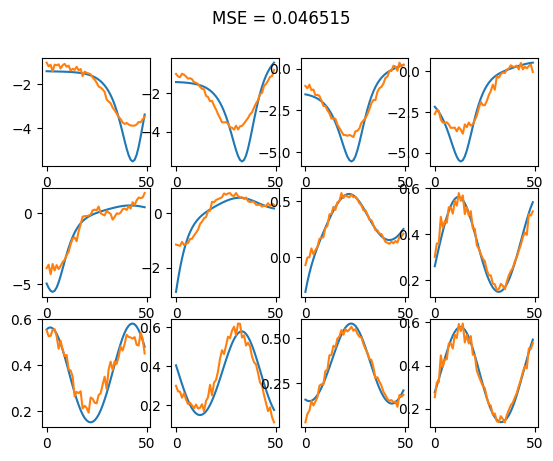

In [24]:
fig, axs = plt.subplots(3, 4)

num_plots = 0
for i in range(3):
    for j in range(4):
        n = (i*4 + j)*10
        axs[i, j].plot(X_windows[0, n, :, 0])
        axs[i, j].plot(recon[0, n, :, 0])
plt.suptitle(f"MSE = {mse:.6f}")
plt.show()

In [ ]:
from JacobianODE.fnn import loss_amplification, loss_false

In [6]:
true_data = torch.from_numpy(data[:4, model.time_window:].reshape(-1, data.shape[-1]))
# append zeros to the end of the data
true_data = torch.cat([true_data, torch.zeros(true_data.shape[0], 10 - true_data.shape[1])], dim=-1)
train_data = data[:4, :, [0]]
pred_data = torch.from_numpy(model.transform(train_data).reshape(-1, 10))
train_data_flat = torch.from_numpy(train_data[:, model.time_window:].reshape(-1, 1))

# work in batches of 100
fnn_losses_true = []
fnn_losses_train = []
fnn_losses_pred = []
amp_losses_true = []
amp_losses_train = []
amp_losses_pred = []

batch_size = 100
for i in range(0, true_data.shape[0], batch_size):
    batch_true = true_data[i:i+batch_size]
    # standardize the batch
    batch_true = (batch_true[:, :3] - batch_true[:, :3].mean(dim=0, keepdim=True)) / batch_true[:, :3].std(dim=0, keepdim=True)
    batch_train = train_data_flat[i:i+batch_size]
    batch_train = (batch_train - batch_train.mean(dim=0, keepdim=True)) / batch_train.std(dim=0, keepdim=True)
    batch_pred = pred_data[i:i+batch_size]
    batch_pred = (batch_pred - batch_pred.mean(dim=0, keepdim=True)) / batch_pred.std(dim=0, keepdim=True)
    fnn_losses_true.append(loss_false(batch_true))
    fnn_losses_train.append(loss_false(batch_train))
    fnn_losses_pred.append(loss_false(batch_pred))
    amp_losses_true.append(loss_amplification(batch_true, batch_train, n_neighbors=10, max_T=5, normalize=True))
    amp_losses_train.append(loss_amplification(batch_train, batch_train, n_neighbors=10, max_T=5, normalize=True))
    amp_losses_pred.append(loss_amplification(batch_pred, batch_train, n_neighbors=10, max_T=5, normalize=True))

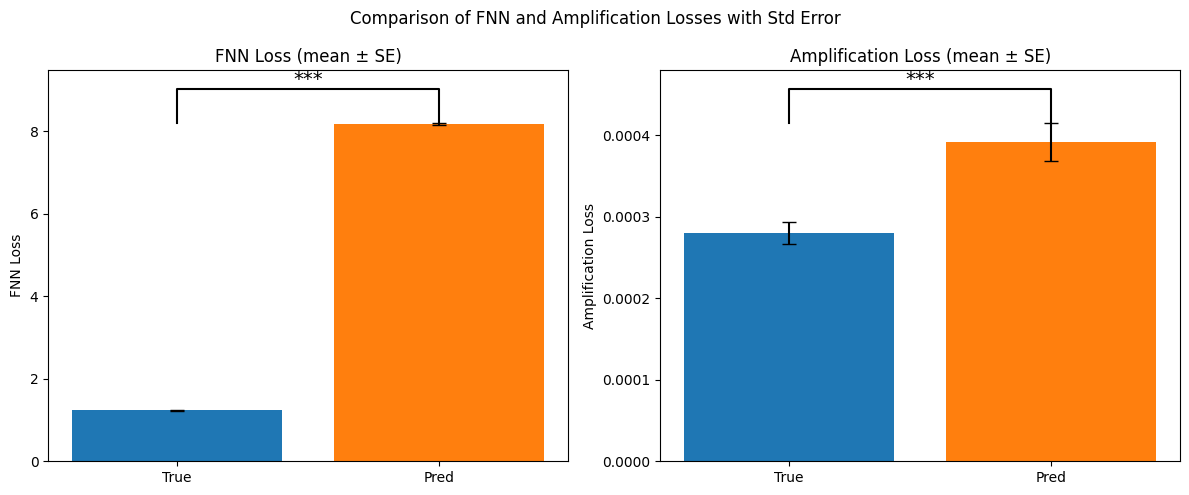

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

plot_train = False

# Convert lists of losses to tensors and stack into arrays
fnn_true = torch.stack(fnn_losses_true).detach().cpu().numpy()
fnn_pred = torch.stack(fnn_losses_pred).detach().cpu().numpy()
fnn_train = torch.stack(fnn_losses_train).detach().cpu().numpy()
amp_true = torch.stack(amp_losses_true).detach().cpu().numpy()
amp_pred = torch.stack(amp_losses_pred).detach().cpu().numpy()
amp_train = torch.stack(amp_losses_train).detach().cpu().numpy()

# Calculate means and standard errors
def mean_and_se(a):
    a = np.array(a)
    mean = np.mean(a)
    se = np.std(a, ddof=1) / np.sqrt(len(a))
    return mean, se

fnn_true_mean, fnn_true_se = mean_and_se(fnn_true)
fnn_train_mean, fnn_train_se = mean_and_se(fnn_train)
fnn_pred_mean, fnn_pred_se = mean_and_se(fnn_pred)
amp_true_mean, amp_true_se = mean_and_se(amp_true)
amp_train_mean, amp_train_se = mean_and_se(amp_train)
amp_pred_mean, amp_pred_se = mean_and_se(amp_pred)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# FNN Losses plot
if plot_train:
    axs[0].bar([0, 1, 2])
    axs[0].set_xticklabels([0, 1, 2], [fnn_true_mean, fnn_train_mean, fnn_pred_mean],
            yerr=[fnn_true_se, fnn_train_se, fnn_pred_se],
            capsize=5, color=['tab:blue', 'tab:green', 'tab:orange'])
    axs[0].set_xticks(['True', 'Train', 'Pred'])
else:
    axs[0].bar([0, 1], [fnn_true_mean, fnn_pred_mean],
            yerr=[fnn_true_se, fnn_pred_se],
            capsize=5, color=['tab:blue', 'tab:orange'])
    axs[0].set_xticks([0, 1])
    axs[0].set_xticklabels(['True', 'Pred'])
axs[0].set_ylabel("FNN Loss")
axs[0].set_title("FNN Loss (mean ± SE)")

# Amp Losses plot
if plot_train:
    axs[1].bar([0, 1, 2], [amp_true_mean, amp_train_mean, amp_pred_mean],
            yerr=[amp_true_se, amp_train_se, amp_pred_se],
            capsize=5, color=['tab:blue', 'tab:green', 'tab:orange'])
    axs[1].set_xticks([0, 1, 2])
    axs[1].set_xticklabels(['True', 'Train', 'Pred'])
else:
    axs[1].bar([0, 1], [amp_true_mean, amp_pred_mean],
            yerr=[amp_true_se, amp_pred_se],
            capsize=5, color=['tab:blue', 'tab:orange'])
    axs[1].set_xticks([0, 1])
    axs[1].set_xticklabels(['True', 'Pred'])
axs[1].set_ylabel("Amplification Loss")
axs[1].set_title("Amplification Loss (mean ± SE)")

# --- Add significance stars (Wilcoxon signed-rank, two-sided) for True vs Pred ---

def add_sig_star(ax, x1, x2, y, pval, height_offset=0.03):
    stars = ""
    if pval < 0.001:
        stars = "***"
    elif pval < 0.01:
        stars = "**"
    elif pval < 0.05:
        stars = "*"
    if stars:
        ax.plot([x1, x1, x2, x2], [y, y+height_offset, y+height_offset, y], lw=1.5, c='k')
        ax.text((x1+x2)/2, y+height_offset, stars, ha='center', va='bottom', fontsize=14, color='k')

# FNN Loss: test if True vs Pred is significant
try:
    stat_fnn, pval_fnn = wilcoxon(fnn_true, fnn_pred, zero_method="wilcox", alternative="two-sided")
except ValueError: # If length 0 or all differences are 0
    pval_fnn = np.nan
max_fnn = max(fnn_true_mean+fnn_true_se, fnn_pred_mean+fnn_pred_se)
if plot_train:
    add_sig_star(axs[0], 0, 2, max_fnn, pval_fnn, height_offset=(max_fnn)*0.1)
else:
    add_sig_star(axs[0], 0, 1, max_fnn, pval_fnn, height_offset=(max_fnn)*0.1)

# Amplification Loss: True vs Pred
try:
    stat_amp, pval_amp = wilcoxon(amp_true, amp_pred, zero_method="wilcox", alternative="two-sided")
except ValueError:
    pval_amp = np.nan
max_amp = max(amp_true_mean+amp_true_se, amp_pred_mean+amp_pred_se)
if plot_train:
    add_sig_star(axs[1], 0, 2, max_amp, pval_amp, height_offset=(max_amp)*0.1)
else:
    add_sig_star(axs[1], 0, 1, max_amp, pval_amp, height_offset=(max_amp)*0.1)

fig.suptitle("Comparison of FNN and Amplification Losses with Std Error")
plt.tight_layout()
plt.show()

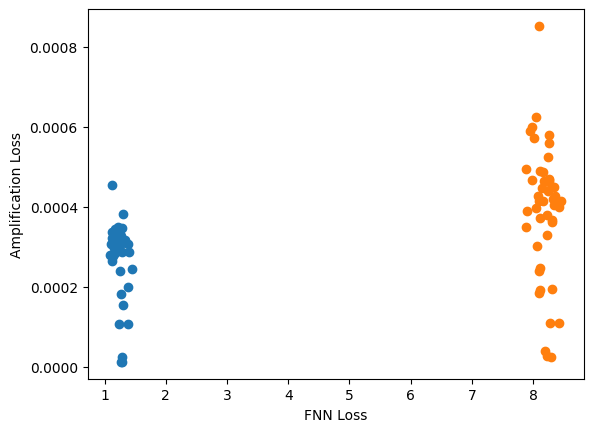

In [63]:
plt.scatter(fnn_true, amp_true)
plt.scatter(fnn_pred, amp_pred)
plt.xlabel("FNN Loss")
plt.ylabel("Amplification Loss")
plt.show()

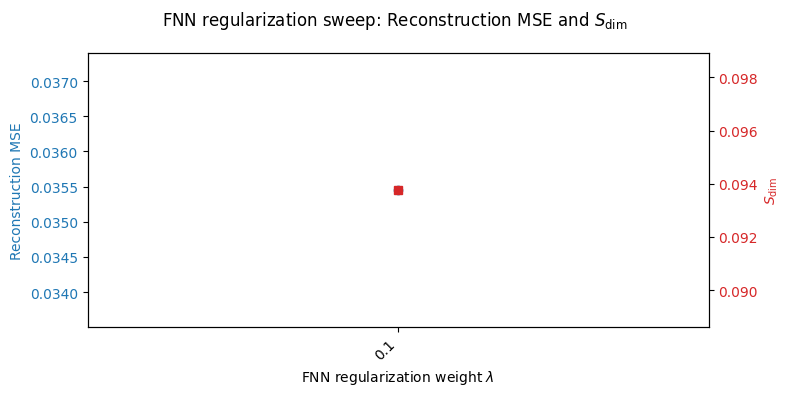

In [64]:
# --- Plot S_dim and Reconstruction MSE vs lambda ---
fig, ax1 = plt.subplots(figsize=(8, 4))

x_labels = [str(v) for v in results["lambda"]]
x_pos = np.arange(len(x_labels))

color_mse = "tab:blue"
ax1.set_xlabel(r"FNN regularization weight $\lambda$")
ax1.set_ylabel("Reconstruction MSE", color=color_mse)
ax1.plot(x_pos, results["mse"], "o-", color=color_mse, label="Recon MSE")
ax1.tick_params(axis="y", labelcolor=color_mse)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, rotation=45, ha="right")

ax2 = ax1.twinx()
color_sdim = "tab:red"
ax2.set_ylabel(r"$S_{\mathrm{dim}}$", color=color_sdim)
ax2.plot(x_pos, results["s_dim"], "s-", color=color_sdim, label=r"$S_{\mathrm{dim}}$")
ax2.tick_params(axis="y", labelcolor=color_sdim)

fig.suptitle(r"FNN regularization sweep: Reconstruction MSE and $S_{\mathrm{dim}}$")
fig.tight_layout()
plt.show()

In [65]:
results["norm_var"][0]

array([1.00000000e+00, 8.23401519e-01, 7.46492293e-01, 3.72978346e-01,
       1.17588401e-01, 4.51008070e-02, 9.17990916e-03, 1.27030627e-03,
       3.66044680e-04, 2.99715485e-04])

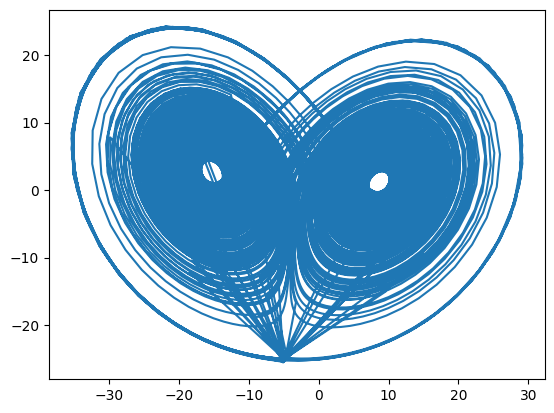

In [66]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
true_data_pca = pca.fit_transform(data.reshape(-1, data.shape[2]))
plt.plot(true_data_pca[:, 0], true_data_pca[:, 1])

In [67]:
model.transform(train_data).shape

(4, 1190, 10)

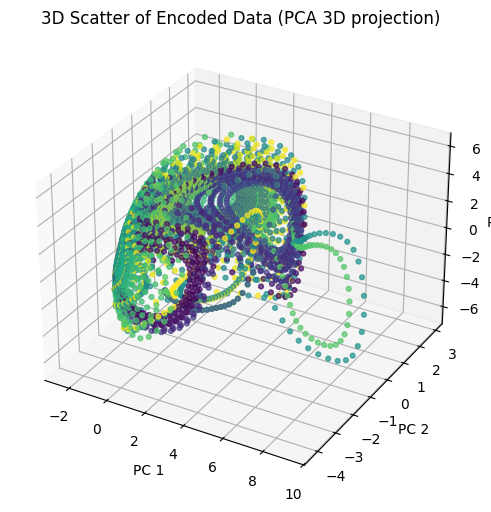

In [69]:

from mpl_toolkits.mplot3d import Axes3D

enc_data = results["model"][-1].transform(train_data)
pca = PCA(n_components=n_latent)
enc_data_pca = pca.fit_transform(enc_data.reshape(-1, n_latent))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    enc_data_pca[:, 0], enc_data_pca[:, 1], enc_data_pca[:, 2],
    c=np.arange(enc_data_pca.shape[0]), cmap="viridis", alpha=0.7, s=12
)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
plt.title("3D Scatter of Encoded Data (PCA 3D projection)")
plt.show()


In [100]:
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

taus = [1, 2, 3, 4, 5]
time_windows = [10, 20, 30, 40, 50, 100, 200]

# Store loss values: axis 0 = tau, axis 1 = time_window
loss_grid = np.zeros((len(taus), len(time_windows)))

iterator = tqdm(total=len(taus) * len(time_windows), desc="Amplification loss landscape")

train_data_noisy = train_data + np.random.normal(0, np.linalg.norm(train_data, axis=-1).mean()*0.0, train_data.shape)

for i, tau in enumerate(taus):
    for j, time_window in enumerate(time_windows):
        etd = ETDEmbedding(n_latent=min((n_latent, time_window//tau, tau*train_data_noisy.shape[-1])), time_window=time_window, tau=tau).fit_transform(train_data_noisy)
        loss = loss_amplification(torch.from_numpy(etd), torch.from_numpy(train_data_noisy), n_neighbors=2, max_T=5, normalize=True)
        # Extract value if loss is tensor
        loss_grid[i, j] = float(loss)
        iterator.update(1)
iterator.close()

Amplification loss landscape:   0%|          | 0/35 [00:00<?, ?it/s]

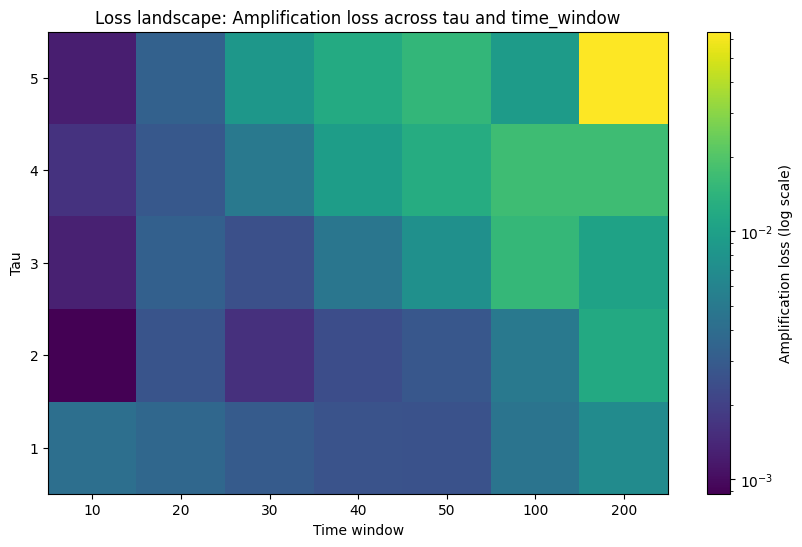

In [101]:
# Plot 2D loss landscape with log-scaled colorbar
from matplotlib.colors import LogNorm

plt.figure(figsize=(10, 6))
im = plt.imshow(
    loss_grid, 
    aspect='auto', 
    origin='lower', 
    interpolation='nearest', 
    cmap="viridis",
    norm=LogNorm(vmin=np.max([np.min(loss_grid[loss_grid > 0]), 1e-10]), vmax=np.max(loss_grid))
)
plt.colorbar(im, label='Amplification loss (log scale)')

# Set ticks so that they are centered on the grid cells
plt.xticks(np.arange(len(time_windows)), time_windows)
plt.yticks(np.arange(len(taus)), taus)
plt.xlabel("Time window")
plt.ylabel("Tau")
plt.title("Loss landscape: Amplification loss across tau and time_window")
plt.show()

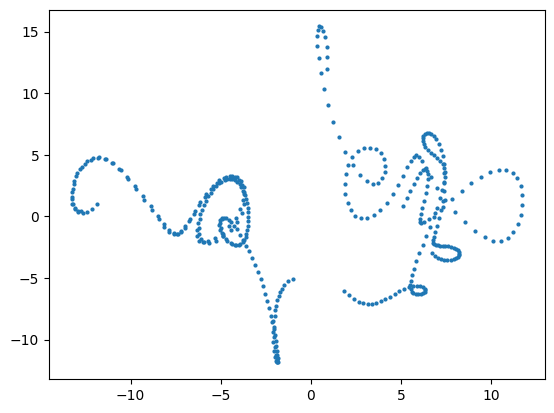

In [103]:
pca = PCA(n_components=2)
etd_2d = pca.fit_transform(etd.reshape(-1, n_latent))
plt.scatter(etd_2d[:, 0], etd_2d[:, 1], s=4)

In [104]:
%%time
loss_amplification(torch.from_numpy(enc_data), torch.from_numpy(train_data), n_neighbors=10, max_T=5, normalize=True)

CPU times: user 363 ms, sys: 25.9 ms, total: 389 ms
Wall time: 575 ms


tensor(0.0079, dtype=torch.float64)

In [105]:
baseline = loss_amplification(torch.from_numpy(data[:4]), torch.from_numpy(train_data), n_neighbors=2, max_T=5, normalize=True)
baseline_v2 = loss_amplification(torch.from_numpy(train_data), torch.from_numpy(train_data), n_neighbors=2, max_T=5, normalize=True)
baseline, baseline_v2

(tensor(9.7954e-09, dtype=torch.float64), tensor(0.0001, dtype=torch.float64))

In [106]:
loss_grid - float(baseline)

array([[0.00418556, 0.0036479 , 0.00299679, 0.00262729, 0.00256192,
        0.00454256, 0.00694076],
       [0.00087436, 0.00265848, 0.0015898 , 0.00239588, 0.00279511,
        0.0049822 , 0.01179223],
       [0.00130452, 0.0032691 , 0.00248746, 0.0046908 , 0.00751646,
        0.01522447, 0.01043308],
       [0.00163994, 0.00284015, 0.00499089, 0.00961248, 0.01237933,
        0.01681189, 0.01678058],
       [0.00126067, 0.00331793, 0.00842839, 0.01210476, 0.01500799,
        0.00928458, 0.06398305]])

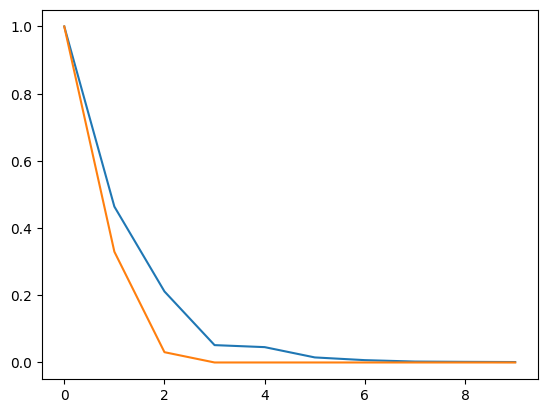

In [107]:
plt.plot(results["norm_var"][-1])
plt.plot(norm_var_true)